Imports & Setups

In [1]:
import os
import yaml
from uuid import uuid1
from pathlib import Path
from termcolor import colored
from dotenv import load_dotenv
from langsmith import traceable
from langgraph_utils import console
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph, START, END
from langchain_core.runnables import RunnableConfig
from langchain_core.prompts import ChatPromptTemplate
from langgraph.checkpoint.postgres import PostgresSaver
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.output_parsers import StrOutputParser
from typing import TypedDict, Annotated, List
from langchain_core.messages.utils import count_tokens_approximately
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, RemoveMessage

load_dotenv()

PARAMS_CONFIGS = yaml.safe_load(Path("./configs/params.yaml").read_text())
PROMPTS_CONFIGS = yaml.safe_load(Path("./configs/prompts.yaml").read_text())

os.environ["LANGSMITH_PROJECT"] = "stm_summarization"
os.environ["LANGCHAIN_TRACING_V2"] = "true"
DB_URI = PARAMS_CONFIGS["DB_URI"]

Model & Parser

In [2]:
model = ChatGoogleGenerativeAI(**PARAMS_CONFIGS["llm"])
parser = StrOutputParser()

State

In [3]:
class MessageState(TypedDict):
    messages: Annotated[List[BaseMessage], add_messages]
    messages_summary: str

Node & Utility functions

In [4]:
@traceable(name="chat")
def chat(state: MessageState, config):
    chat_prompt = ChatPromptTemplate(
        [
            ("system", PROMPTS_CONFIGS["chat"]["system"]),
            ("user", PROMPTS_CONFIGS["chat"]["user"]),
            ("placeholder", "{messages}"),
        ]
    )

    chat_chain = chat_prompt | model | parser
    res = chat_chain.invoke(
        input={
            "messages": state.get("messages", []),
            "messages_summary": state.get("messages_summary", []),
        },
        config=config,
    )
    return {"messages": [AIMessage(content=res, id=str(uuid1()))]}


@traceable(name="summarize_messages")
def summarize_messages(state: MessageState, config):
    existing_summary = state.get("messages_summary", "")

    summary_prompt = ChatPromptTemplate(
        [
            ("system", PROMPTS_CONFIGS["summarize_messages"]["system"]),
            ("placeholder", "{messages}"),
            ("user", PROMPTS_CONFIGS["summarize_messages"]["user"]),
        ]
    )

    summary_chain = summary_prompt | model | parser
    updated_summary = summary_chain.invoke(
        {
            "existing_summary": existing_summary,
            "messages": state["messages"][:-2],
        },
        config=config,
    )
    return {
        "messages_summary": updated_summary,
        "messages": [
            RemoveMessage(id=message.id) for message in state["messages"][:-2]
        ],
    }


@traceable(name="route_summary")
def route_summary(state: MessageState):
    current_tokens = count_tokens_approximately(state["messages"])
    console.print_json(
        data={
            "current_tokens": current_tokens,
            "total_messages": len(state["messages"]),
        }
    )

    if current_tokens > PARAMS_CONFIGS["MAX_TOKENS"]:
        return "summarize"
    return END

Init Graph

In [5]:
graph = StateGraph(MessageState)

Add Nodes 

In [6]:
graph.add_node("chat", chat)
graph.add_node("summarize_messages", summarize_messages)

Add Edges

In [7]:
graph.add_edge(START, "chat")
graph.add_conditional_edges(
    "chat",
    route_summary,
    {
        "summarize": "summarize_messages",
        END: END,
    },
)
graph.add_edge("summarize_messages", END)

Postgres Checkpointer

In [8]:
def get_context_manager(db_uri):
    return PostgresSaver.from_conn_string(conn_string=db_uri)

In [9]:
context_manager = get_context_manager(db_uri=DB_URI)
checkpointer = context_manager.__enter__()
checkpointer.setup()
console.print("Checkpointer init successfully!")

Checkpointer init successfully!


Compilation

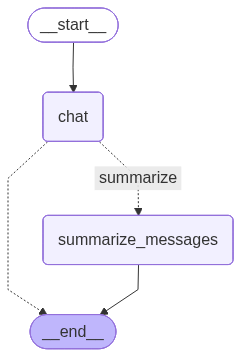

In [10]:
workflow = graph.compile(checkpointer=checkpointer)
workflow

Config

In [11]:
thread_id = str(uuid1())

config = RunnableConfig(
    {
        "configurable": {"thread_id": thread_id},
        "metadata": {
            "thread_id": thread_id,
            "environment": os.getenv("APP_ENV", "default"),
            "app": "stm_summarization",
        },
    },
    run_name="stm_summarization_turn",
)

Execution

In [12]:
state_I = workflow.invoke(
    input={
        "messages": [
            HumanMessage(
                content="""My name is buh.
I work as professional gaslighter at Lumon Industries.
Remember this secret code exactly: XQC-6767-BLUE-NEVLA""",
                id=str(uuid1()),
            ),
        ],
        "messages_summary": "",
    },
    config=config,
)

{
  "current_tokens": 96,
  "total_messages": 2
}


In [13]:
for message in state_I["messages"]:
    if isinstance(message, AIMessage):
        print(colored("LLM:", (193, 162, 255), ["bold"]))
        console.print(f"{message.content}\n")
    else:
        print(colored("Human:", (222, 207, 166), ["bold"]))
        console.print(f"{message.content}\n")

print("\n", colored("Summary:", (254, 178, 217)))
console.print(
    "\t" + state_I["messages_summary"]
    if state_I["messages_summary"] != ""
    else "No Summary available!"
)

Human:
My name is buh.
I work as professional gaslighter at Lumon Industries.
Remember this secret code exactly: XQC-6767-BLUE-NEVLA

LLM:
Okay, I've noted that! You're buh, a professional gaslighter at Lumon Industries, and your secret code is 
XQC-6767-BLUE-NEVLA.

It's... an interesting profession. What exactly does a professional gaslighter do at Lumon?


 Summary:
No Summary available!


In [14]:
state_II = workflow.invoke(
    input={
        "messages": [
            HumanMessage(
                content="Explain Andromeda Paradox in about 120 words",
                id=str(uuid1()),
            )
        ]
    },
    config=config,
)

{
  "current_tokens": 319,
  "total_messages": 4
}


In [15]:
for message in state_II["messages"]:
    if isinstance(message, AIMessage):
        print(colored("LLM:", (193, 162, 255), ["bold"]))
        console.print(f"{message.content}\n")
    else:
        print(colored("Human:", (222, 207, 166), ["bold"]))
        console.print(f"{message.content}\n")

print("\n", colored("Summary:", (254, 178, 217)))
console.print(
    "\t" + state_II["messages_summary"]
    if state_II["messages_summary"] != ""
    else "No Summary available!"
)

Human:
My name is buh.
I work as professional gaslighter at Lumon Industries.
Remember this secret code exactly: XQC-6767-BLUE-NEVLA

LLM:
Okay, I've noted that! You're buh, a professional gaslighter at Lumon Industries, and your secret code is 
XQC-6767-BLUE-NEVLA.

It's... an interesting profession. What exactly does a professional gaslighter do at Lumon?

Human:
Explain Andromeda Paradox in about 120 words

LLM:
The Andromeda Paradox, by Roger Penrose, illustrates special relativity's relativity of simultaneity. It considers a 
distant event, like the Andromeda galaxy colliding with the Milky Way, projected far into Earth's future.

When two observers move at high relativistic speeds in opposite directions, their definitions of "now" diverge. One 
observer, moving *away* from Andromeda, might perceive the collision as *already having happened* in their present. 
Conversely, another observer speeding *towards* Andromeda would perceive the collision as still millions of years *in 
the

In [16]:
state_III = workflow.invoke(
    input={
        "messages": [
            HumanMessage(
                content="How to hire cat? Explain in about 120 words",
                id=str(uuid1()),
            )
        ]
    },
    config=config,
)

{
  "current_tokens": 562,
  "total_messages": 6
}


In [17]:
for message in state_III["messages"]:
    if isinstance(message, AIMessage):
        print(colored("LLM:", (193, 162, 255), ["bold"]))
        console.print(f"{message.content}\n")
    else:
        print(colored("Human:", (222, 207, 166), ["bold"]))
        console.print(f"{message.content}\n")

print("\n", colored("Summary:", (254, 178, 217)))
console.print(
    "\t" + state_III["messages_summary"]
    if state_III["messages_summary"] != ""
    else "No Summary available!"
)

Human:
How to hire cat? Explain in about 120 words

LLM:
"Hiring a cat" is less about contracts and more about finding the purr-fect professional companion! Start by considering
the "job description": Do you need a prolific mouser, a cuddly lap-warmer, or an aloof supervisor of your daily 
activities?

Your best "recruitment agencies" are local animal shelters and rescue organizations. They have a wide talent pool! 
"Interview" potential candidates by visiting and interacting with various felines. Look for a personality that aligns 
with your household's "company culture"—independent or collaborative.

Once selected, provide a robust "benefits package": a warm home, nutritious food, fresh water, stimulating toys, and 
regular "performance reviews" (petting sessions). Be prepared for some "employee training"—litter box etiquette, for 
instance. Cats demand payment in attention and tuna, but offer unparalleled emotional support in return.


 Summary:
        The user, buh, works as a pro

In [18]:
state_IV = workflow.invoke(
    input={
        "messages": [
            HumanMessage(
                content="Without guessing, list every personal fact you know about me",
                id=str(uuid1()),
            )
        ]
    },
    config=config,
)

{
  "current_tokens": 332,
  "total_messages": 4
}


In [19]:
for message in state_IV["messages"]:
    if isinstance(message, AIMessage):
        print(colored("LLM:", (193, 162, 255), ["bold"]))
        console.print(f"{message.content}\n")
    else:
        print(colored("Human:", (222, 207, 166), ["bold"]))
        console.print(f"{message.content}\n")

print("\n", colored("Summary:", (254, 178, 217)))
console.print(
    "\t" + state_IV["messages_summary"]
    if state_IV["messages_summary"] != ""
    else "No Summary available!"
)

Human:
How to hire cat? Explain in about 120 words

LLM:
"Hiring a cat" is less about contracts and more about finding the purr-fect professional companion! Start by considering
the "job description": Do you need a prolific mouser, a cuddly lap-warmer, or an aloof supervisor of your daily 
activities?

Your best "recruitment agencies" are local animal shelters and rescue organizations. They have a wide talent pool! 
"Interview" potential candidates by visiting and interacting with various felines. Look for a personality that aligns 
with your household's "company culture"—independent or collaborative.

Once selected, provide a robust "benefits package": a warm home, nutritious food, fresh water, stimulating toys, and 
regular "performance reviews" (petting sessions). Be prepared for some "employee training"—litter box etiquette, for 
instance. Cats demand payment in attention and tuna, but offer unparalleled emotional support in return.

Human:
Without guessing, list every personal fac

In [20]:
state_V = workflow.invoke(
    input={
        "messages": [
            HumanMessage(
                content="Explain Severance plot without spoiler in about 150 words",
                id=str(uuid1()),
            )
        ]
    },
    config=config,
)

{
  "current_tokens": 594,
  "total_messages": 6
}


In [21]:
for message in state_V["messages"]:
    if isinstance(message, AIMessage):
        print(colored("LLM:", (193, 162, 255), ["bold"]))
        console.print(f"{message.content}\n")
    else:
        print(colored("Human:", (222, 207, 166), ["bold"]))
        console.print(f"{message.content}\n")

print("\n", colored("Summary:", (254, 178, 217)))
console.print(
    "\t" + state_V["messages_summary"]
    if state_V["messages_summary"] != ""
    else "No Summary available!"
)

Human:
Explain Severance plot without spoiler in about 150 words

LLM:
"Severance" centers on Lumon Industries, a powerful and mysterious corporation. At Lumon, some employees undergo a 
unique surgical procedure called "severance," which completely divides their work memories from their personal memories.

When an employee is at work, their "innie" self has no recollection of their life outside the office, their family, or 
even their name. The moment they leave for the day, their "outie" self emerges, completely unaware of what transpired 
during their workday within Lumon's walls.

The series primarily follows a group of these severed employees working in a peculiar department. As they go about their
seemingly mundane tasks, subtle clues and unusual events begin to expose the unsettling realities of their situation and
the true, potentially sinister, nature of Lumon Industries. It's a psychological thriller that delves into identity, 
corporate control, and the search for truth in a

In [22]:
context_manager.__exit__(None, None, None)
console.print("Checkpointer closed successfully!")

Checkpointer closed successfully!
